## Phase 1: Data Cleaning

In [32]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Rishabh Pandey\OneDrive\Desktop\SEM2 Project\US_Accidents_March23.csv", nrows=200000)

df.head(10)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day
5,A-6,Source2,3,2016-02-08 07:44:26,2016-02-08 08:14:26,40.100590,-82.925194,NaN,NaN,0.01,...,False,False,False,False,False,False,Day,Day,Day,Day
6,A-7,Source2,2,2016-02-08 07:59:35,2016-02-08 08:29:35,39.758274,-84.230507,NaN,NaN,0.00,...,False,False,False,False,False,False,Day,Day,Day,Day
7,A-8,Source2,3,2016-02-08 07:59:58,2016-02-08 08:29:58,39.770382,-84.194901,NaN,NaN,0.01,...,False,False,False,False,False,False,Day,Day,Day,Day
8,A-9,Source2,2,2016-02-08 08:00:40,2016-02-08 08:30:40,39.778061,-84.172005,NaN,NaN,0.00,...,False,False,False,False,False,False,Day,Day,Day,Day
9,A-10,Source2,3,2016-02-08 08:10:04,2016-02-08 08:40:04,40.100590,-82.925194,NaN,NaN,0.01,...,False,False,False,False,False,False,Day,Day,Day,Day


In [33]:
#df.shape
print(df.isnull().sum())

print(df.columns)

ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  200000
End_Lng                  200000
Distance(mi)                  0
Description                   0
Street                        0
City                         14
County                        0
State                         0
Zipcode                      30
Country                       0
Timezone                     30
Airport_Code                 30
Weather_Timestamp          1543
Temperature(F)             2835
Wind_Chill(F)            178610
Humidity(%)                3243
Pressure(in)               2203
Visibility(mi)             3263
Wind_Direction             1556
Wind_Speed(mph)           38440
Precipitation(in)        181648
Weather_Condition          2788
Amenity                       0
Bump                          0
Crossing

In [34]:
df = df.drop(['Wind_Chill(F)', 'Precipitation(in)'], axis=1)
print('Wind_Chill(F)' in df.columns)
print('Precipitation(in)' in df.columns)

False
False


In [35]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])
df['Start_Time']

0        2016-02-08 05:46:00
1        2016-02-08 06:07:59
2        2016-02-08 06:49:27
3        2016-02-08 07:23:34
4        2016-02-08 07:39:07
                 ...        
199995   2017-01-12 06:12:42
199996   2017-01-12 06:15:23
199997   2017-01-12 06:12:02
199998   2017-01-12 06:09:29
199999   2017-01-12 06:08:14
Name: Start_Time, Length: 200000, dtype: datetime64[ns]

In [36]:
df['Hour'] = df['Start_Time'].dt.hour
df['Hour']

0         5
1         6
2         6
3         7
4         7
         ..
199995    6
199996    6
199997    6
199998    6
199999    6
Name: Hour, Length: 200000, dtype: int32

In [37]:
df['Year'] = df['Start_Time'].dt.year
df['Year']

0         2016
1         2016
2         2016
3         2016
4         2016
          ... 
199995    2017
199996    2017
199997    2017
199998    2017
199999    2017
Name: Year, Length: 200000, dtype: int32

## Phase 2: Road Type Engineering

In [38]:
df['Night_Flag'] = df['Hour'].apply(lambda x: 1 if x >= 20 or x <= 6 else 0)

df[['Hour','Night_Flag']].head()

,Hour,Night_Flag
0,5,1
1,6,1
2,6,1
3,7,0
4,7,0


In [39]:
bad_weather = ['Rain','Snow','Fog','Storm']

df['Bad_Weather_Flag'] = df['Weather_Condition'].apply(
    lambda x: 1 if any(w in str(x) for w in bad_weather) else 0
)
df['Bad_Weather_Flag'] 

0         1
1         1
2         0
3         0
4         0
         ..
199995    0
199996    0
199997    0
199998    0
199999    0
Name: Bad_Weather_Flag, Length: 200000, dtype: int64

In [40]:
df[['Weather_Condition','Bad_Weather_Flag']].head()

,Weather_Condition,Bad_Weather_Flag
0,Light Rain,1
1,Light Rain,1
2,Overcast,0
3,Mostly Cloudy,0
4,Mostly Cloudy,0


In [41]:
#accidents in normal weather
#accidents in bad weather
df['Bad_Weather_Flag'].value_counts()

Bad_Weather_Flag
0    187793
1     12207
Name: count, dtype: int64

In [42]:
#Build Road_Type column
def road_type(street):

    street = str(street).lower()

    if "interstate" in street or "i-" in street or "highway" in street or "hwy" in street:
        return "Highway"

    elif "st" in street or "street" in street or "ave" in street or "avenue" in street:
        return "Urban"

    elif "junction" in street or "crossing" in street:
        return "Junction"

    else:
        return "Other"

df['Road_Type'] = df['Street'].apply(road_type)
df['Road_Type']

0         Highway
1           Other
2           Urban
3         Highway
4           Other
           ...   
199995      Other
199996      Other
199997      Other
199998      Urban
199999      Urban
Name: Road_Type, Length: 200000, dtype: object

In [43]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Hour,Year,Night_Flag,Bad_Weather_Flag,Road_Type
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,Night,Night,Night,Night,5,2016,1,1,Highway
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,Night,Night,Night,Day,6,2016,1,1,Other
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,Night,Night,Day,Day,6,2016,1,0,Urban
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,Night,Day,Day,Day,7,2016,0,0,Highway
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,Day,Day,Day,Day,7,2016,0,0,Other


In [44]:
df[['Street','Road_Type']].head(10)

,Street,Road_Type
0,I-70 E,Highway
1,Brice Rd,Other
2,State Route 32,Urban
3,I-75 S,Highway
4,Miamisburg Centerville Rd,Other
5,Westerville Rd,Urban
6,N Woodward Ave,Urban
7,N Main St,Urban
8,Notre Dame Ave,Urban
9,Westerville Rd,Urban


In [45]:
df.to_csv("US_Accidents_Cleaned.csv", index=False)

## Phase 3 Risk Component Calculation

In [46]:
df["Road_Type"].value_counts()

Road_Type
Other       99030
Highway     51080
Urban       49856
Junction       34
Name: count, dtype: int64

In [47]:
freq=df.groupby("Road_Type")["Severity"].size()/len(df)
freq

Road_Type
Highway     0.25540
Junction    0.00017
Other       0.49515
Urban       0.24928
Name: Severity, dtype: float64

In [48]:
severity=df.groupby("Road_Type")["Severity"].mean()
severity

Road_Type
Highway     2.806539
Junction    2.235294
Other       2.295042
Urban       2.232429
Name: Severity, dtype: float64

In [49]:
weather_ratio = df.groupby("Road_Type")["Bad_Weather_Flag"].mean()
weather_ratio

Road_Type
Highway     0.065799
Junction    0.000000
Other       0.056549
Urban       0.065108
Name: Bad_Weather_Flag, dtype: float64

In [50]:
night_ratio=df.groupby("Road_Type")["Night_Flag"].mean()
night_ratio

Road_Type
Highway     0.255540
Junction    0.264706
Other       0.241119
Urban       0.204770
Name: Night_Flag, dtype: float64

In [51]:
visibility = df.groupby("Road_Type")["Visibility(mi)"].mean()
visibility_risk = 1 / visibility
visibility_risk

Road_Type
Highway     0.107982
Junction    0.108197
Other       0.107532
Urban       0.107911
Name: Visibility(mi), dtype: float64

In [52]:
risk_table = pd.DataFrame({
    "Frequency": freq,
    "Severity": severity,
    "Weather": weather_ratio,
    "Night": night_ratio,
    "Visibility": visibility_risk
})
risk_table

,Frequency,Severity,Weather,Night,Visibility
Road_Type,,,,,
Highway,0.25540,2.806539,0.065799,0.255540,0.107982
Junction,0.00017,2.235294,0.000000,0.264706,0.108197
Other,0.49515,2.295042,0.056549,0.241119,0.107532
Urban,0.24928,2.232429,0.065108,0.204770,0.107911


In [53]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

risk_table_scaled = pd.DataFrame(
    scaler.fit_transform(risk_table),
    columns=risk_table.columns,
    index=risk_table.index
)

risk_table_scaled["Risk_Index"] = (
    0.35 * risk_table_scaled["Severity"] +
    0.25 * risk_table_scaled["Frequency"] +
    0.15 * risk_table_scaled["Weather"] +
    0.15 * risk_table_scaled["Night"] +
    0.10 * risk_table_scaled["Visibility"]
)


risk_table_scaled.sort_values("Risk_Index", ascending=False)

,Frequency,Severity,Weather,Night,Visibility,Risk_Index
Road_Type,,,,,,
Highway,0.515637,1.00000,1.000000,0.847078,0.676486,0.823620
Other,1.000000,0.10906,0.859416,0.606464,0.000000,0.508053
Urban,0.503273,0.00000,0.989495,0.000000,0.570483,0.331291
Junction,0.000000,0.00499,0.000000,1.000000,1.000000,0.251746


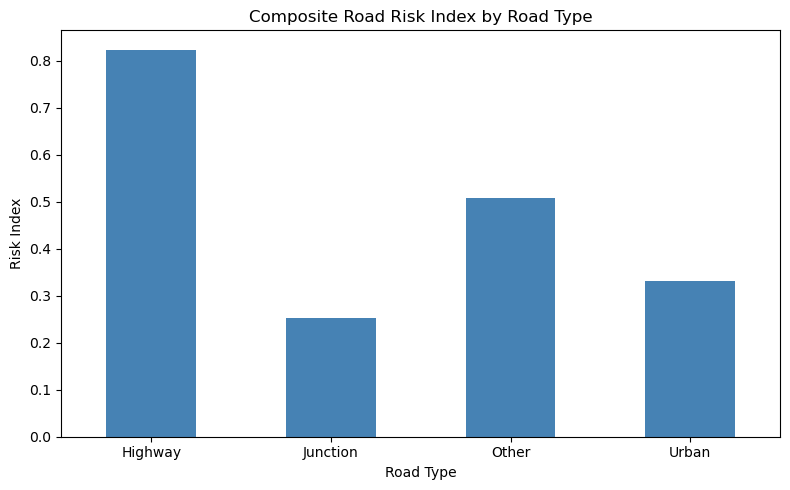

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

risk_table_scaled["Risk_Index"].plot(
    kind="bar",
    color="steelblue"
)

plt.xlabel("Road Type")
plt.ylabel("Risk Index")
plt.title("Composite Road Risk Index by Road Type")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [55]:
risk_table_scaled.to_csv("risk_table_scaled.csv")

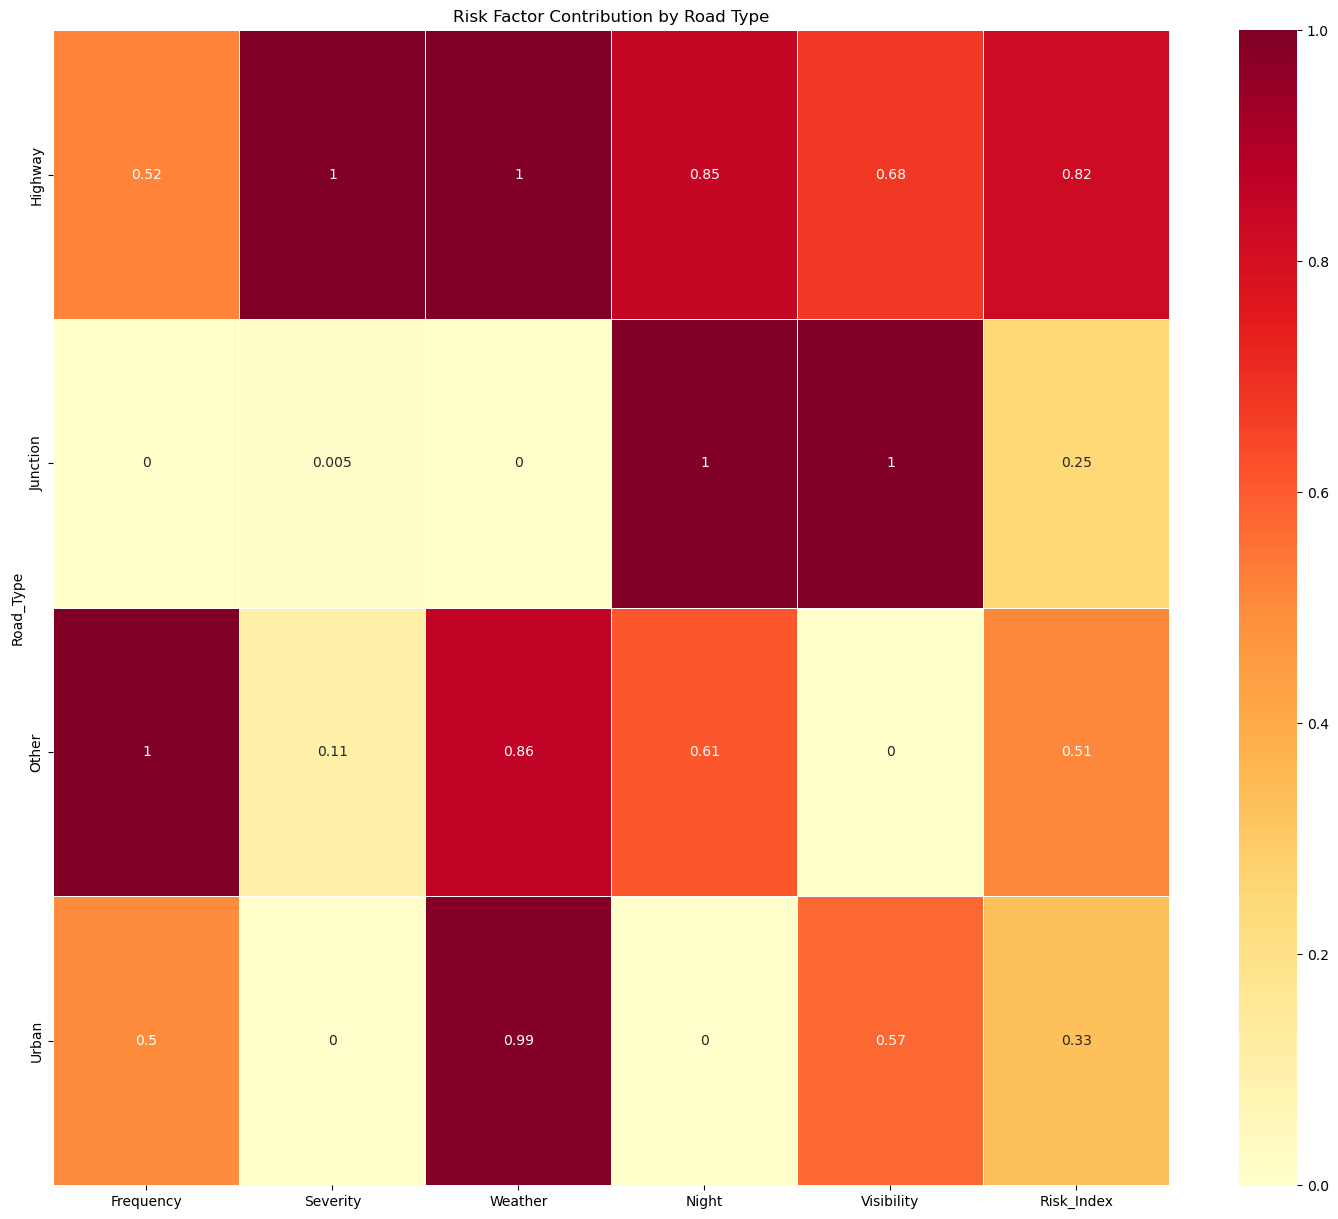

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,15))

sns.heatmap(
    risk_table_scaled,
    annot=True,
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Risk Factor Contribution by Road Type")
plt.show()
